#### Setup

In [1]:
# Importing Libraries
from sqlalchemy import create_engine

# Details
host = 'localhost'
user = 'root'
password = ''# Password removed for security
database = 'bellabeat'

engine = create_engine(f"mysql+pymysql://{user}:{password}@{host}/{database}")

#### Fetching Data

In [2]:
df_activity        = pd.read_sql("SELECT * FROM dailyactivity_merged", engine)
df_sleep           = pd.read_sql("SELECT * FROM sleepday_merged", engine)
df_weight          = pd.read_sql("SELECT * FROM weightloginfo_merged", engine)
df_calories        = pd.read_sql("SELECT * FROM dailycalories_merged", engine)
df_intensities     = pd.read_sql("SELECT * FROM dailyintensities_merged", engine)
df_heartrate       = pd.read_sql("SELECT * FROM heartrate_seconds_merged", engine)
df_steps_daily     = pd.read_sql("SELECT * FROM dailysteps_merged", engine)
df_steps_hourly    = pd.read_sql("SELECT * FROM hourlysteps_merged", engine)
df_calories_hourly = pd.read_sql("SELECT * FROM hourlycalories_merged", engine)
df_intensity_hourly= pd.read_sql("SELECT * FROM hourlyintensities_merged", engine)
df_calories_minute = pd.read_sql("SELECT * FROM minutecalorieswide_merged", engine)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#### Data Visualizations

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

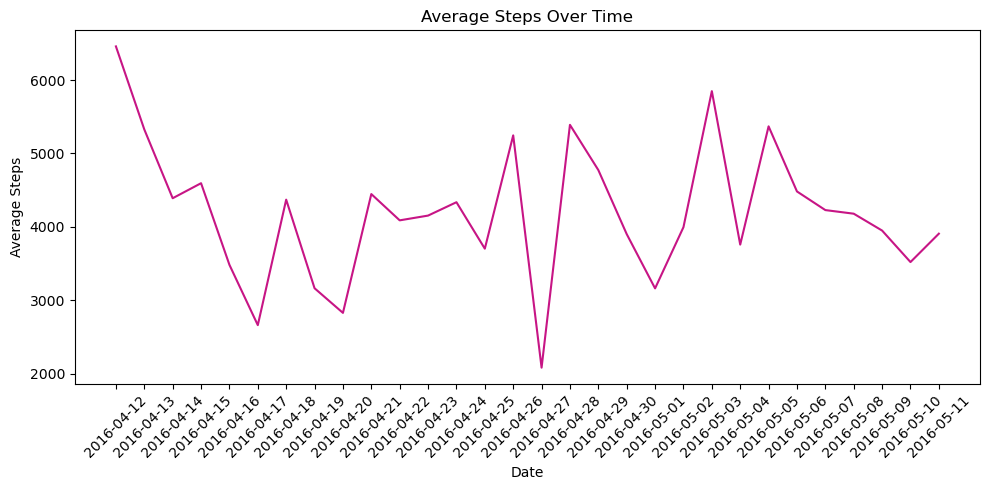

In [7]:
df_avg_steps = df_activity.groupby('activitydate')['totalsteps'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=df_avg_steps, x='activitydate', y='totalsteps', color='mediumvioletred')
plt.title('Average Steps Over Time')
plt.xlabel('Date')
plt.ylabel('Average Steps')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insights

 The daily step counts fluctuate quite a bit over the period, starting high, then dropping sharply before bouncing back and forth. There’s no steady trend upwards or downwards, suggesting inconsistent physical activity — some days are very active, while others much less so.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

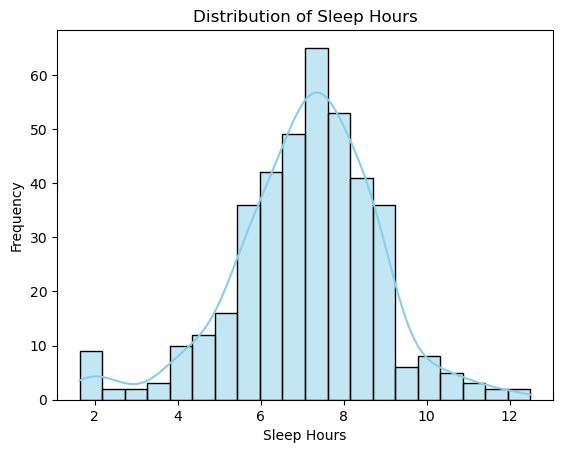

In [8]:
sns.histplot(df_sleep['sleep_hours'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Sleep Hours')
plt.xlabel('Sleep Hours')
plt.ylabel('Frequency')
plt.show()

### Insights

Most people seem to get between 6 and 8 hours of sleep, with the highest frequencies around 7 hours. The distribution is roughly bell-shaped, indicating that while most have a typical sleep duration, there are a few who sleep much less or much more.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

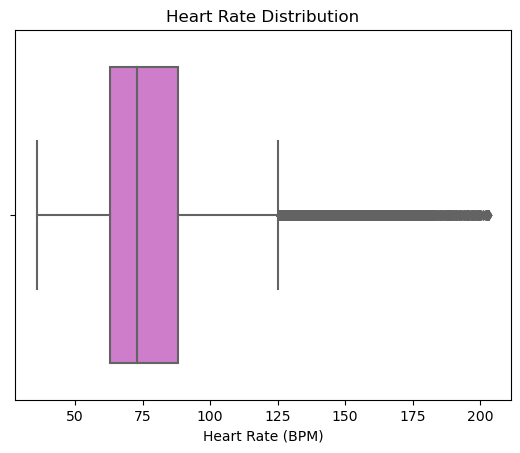

In [9]:
sns.boxplot(x=df_heartrate['value'], color='orchid')
plt.title('Heart Rate Distribution')
plt.xlabel('Heart Rate (BPM)')
plt.show()

### Insights

The heart rate data centers mostly between about 60 and 90 beats per minute, which is normal for resting heart rates. However, there are a scattered few high outliers beyond 200 bpm, which might be errors or exceptional cases, but overall, the heart rates are fairly consistent.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

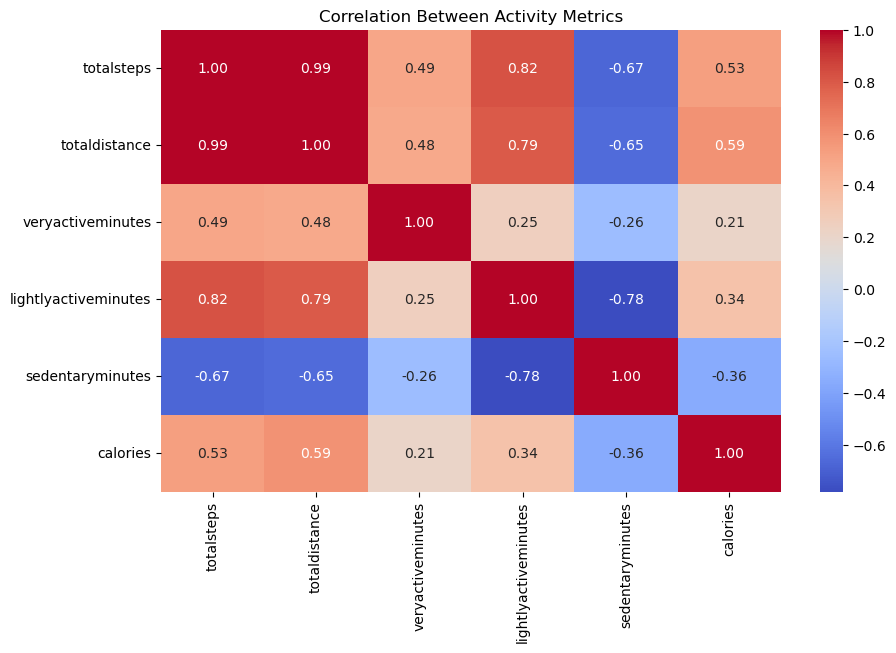

In [10]:
activity_corr = df_activity[[
    'totalsteps', 'totaldistance', 'veryactiveminutes',
    'lightlyactiveminutes', 'sedentaryminutes', 'calories'
]].corr()

plt.figure(figsize=(10,6))
sns.heatmap(activity_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Activity Metrics')
plt.show()

### Insights

There are strong positive correlations between steps, distance, and light activity, which makes sense since more steps naturally mean more distance and activity. Sedentary minutes negatively correlate with active metrics, meaning more sitting time relates to less movement. Calories burned somewhat correlate with active metrics but less strongly, likely due to other factors influencing calorie burn. 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

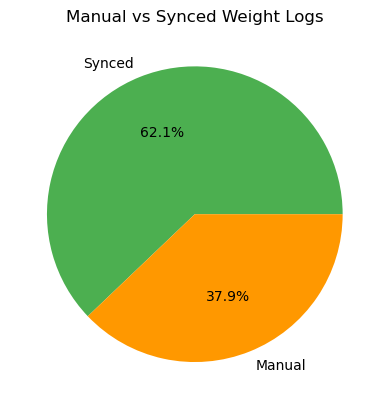

In [12]:
manual_count = df_weight['ismanualreport'].value_counts()

manual_count.plot.pie(labels=['Synced', 'Manual'], autopct='%1.1f%%', colors=['#4CAF50', '#FF9800'])
plt.title('Manual vs Synced Weight Logs')
plt.ylabel('')
plt.show()


### Insights

Interestingly, most weight logs come from synced devices (about 62%), but a large chunk (about 38%) is logged manually. This mix suggests users rely on both automated tracking and personal entries, highlighting the importance of flexibility in logging methods.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

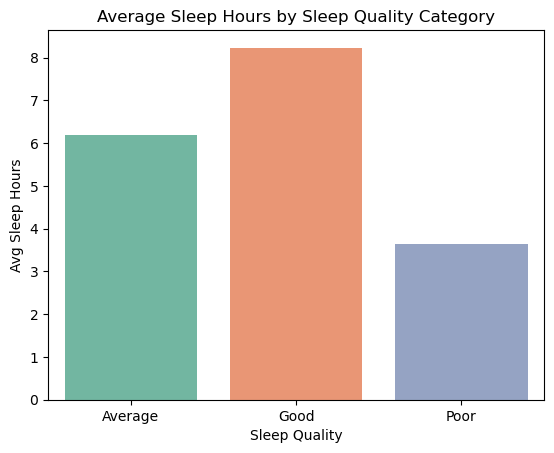

In [13]:
df_sleep['sleep_hours'] = df_sleep['totalminutesasleep'] / 60

def classify_sleep(hours):
    if hours < 5:
        return 'Poor'
    elif hours < 7:
        return 'Average'
    else:
        return 'Good'

df_sleep['SleepQuality'] = df_sleep['sleep_hours'].apply(classify_sleep)
avg_sleep = df_sleep.groupby('SleepQuality')['sleep_hours'].mean().reset_index()

sns.barplot(data=avg_sleep, x='SleepQuality', y='sleep_hours', palette='Set2')
plt.title('Average Sleep Hours by Sleep Quality Category')
plt.xlabel('Sleep Quality')
plt.ylabel('Avg Sleep Hours')
plt.show()


### Insights

People who report "Good" sleep quality tend to sleep the longest on average (over 8 hours), while those with "Poor" sleep quality average less than 4 hours. Those who rate their sleep as "Average" fall in between, indicating a clear link between longer sleep durations and better subjective sleep quality.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

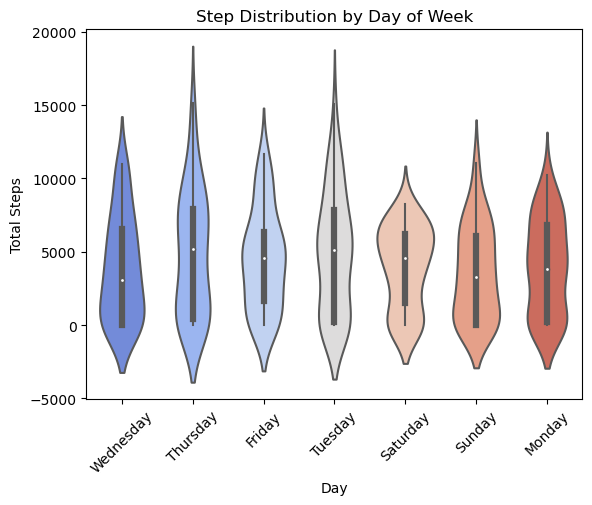

In [14]:
df_activity['activitydate'] = pd.to_datetime(df_activity['activitydate'])
df_activity['DayOfWeek'] = df_activity['activitydate'].dt.day_name()

sns.violinplot(data=df_activity, x='DayOfWeek', y='totalsteps', palette='coolwarm')
plt.title('Step Distribution by Day of Week')
plt.ylabel('Total Steps')
plt.xlabel('Day')
plt.xticks(rotation=45)
plt.show()

### Insights

Looking at the step distribution by day of the week, it’s clear that Tuesday and Thursday tend to be the most active days, often with higher median and maximum step counts. Wednesday and Friday also show fairly high activity but with a bit more spread in the data. Weekends (Saturday and Sunday) appear to have slightly lower median steps and less variation overall, suggesting people might be less active or have more consistent but lower activity on these days. Monday is somewhere in the middle, but still not as active as Tuesday or Thursday. Overall, it seems like midweek days get more movement, possibly reflecting workweek routines, while activity dips slightly during the weekend.